# Practice 11 — Dataloader

ML 학습에 필요한 **데이터 준비 파이프라인**을 구축합니다.

| 단계 | 내용 |
|------|------|
| `train_test_split` | 데이터를 훈련/검증/테스트 세트로 분할 |
| 표준화 (Standardization) | train 통계로 모든 세트를 변환 |
| `TensorDataset` | NumPy → PyTorch Dataset 변환 |
| `DataLoader` | 미니배치 순회 + 셔플 |


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)


---
# 1. 데이터 준비와 분할 (Data Preparation & Splitting)

학습에 사용할 데이터를 불러오고, **훈련/검증/테스트** 세 부분으로 나눕니다.

| 세트 | 비율 | 용도 |
|------|------|------|
| Training | 60% | 모델 학습 (가중치 업데이트) |
| Validation | 20% | 학습 중 성능 모니터링 (하이퍼파라미터 튜닝) |
| Test | 20% | 최종 성능 평가 (학습에 절대 사용하지 않음) |

Data shape  : (1797, 64)
Target shape: (1797,)
Classes     : [0 1 2 3 4 5 6 7 8 9]
Pixel range : 0 ~ 16


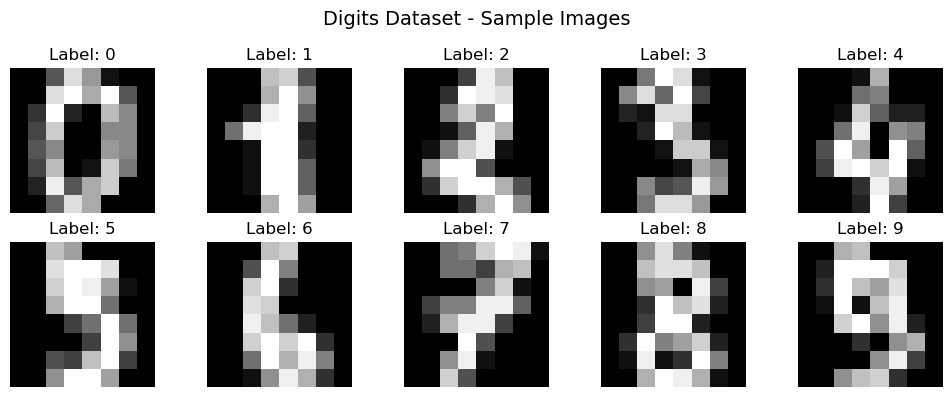

In [2]:
# sklearn의 digits 데이터셋: 8x8 손글씨 숫자 (0~9)
digits = load_digits()
X, y = digits.data, digits.target  # (1797, 64), (1797,)

print(f"Data shape  : {X.shape}")       # 1797개 샘플, 64개 특징 (8x8 이미지)
print(f"Target shape: {y.shape}")
print(f"Classes     : {np.unique(y)}")   # 0~9
print(f"Pixel range : {X.min():.0f} ~ {X.max():.0f}")

# 샘플 이미지 확인
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.suptitle('Digits Dataset - Sample Images', fontsize=14)
plt.tight_layout(); plt.show()

In [3]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [4]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [5]:
# ========== 데이터 분할: 60% train / 20% val / 20% test ==========

# (1) 먼저 train+val (80%) vs test (20%) 로 분리
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# (2) train+val에서 train (75% of 80% = 60%) vs val (25% of 80% = 20%) 로 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})")
print(f"Val   : {X_val.shape[0]} samples ({X_val.shape[0]/len(X):.0%})")
print(f"Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})")

Train : 1077 samples (60%)
Val   : 360 samples (20%)
Test  : 360 samples (20%)


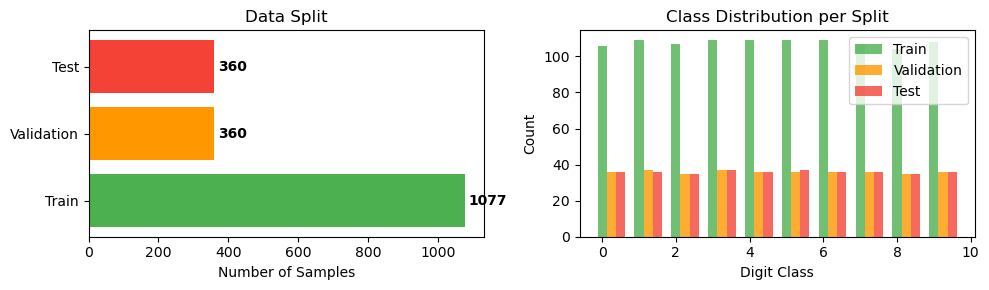

In [6]:
# 분할 결과 시각화
sizes = [len(X_train), len(X_val), len(X_test)]
labels = ['Train', 'Validation', 'Test']
colors = ['#4CAF50', '#FF9800', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# (1) 분할 비율
axes[0].barh(labels, sizes, color=colors)
for i, (s, l) in enumerate(zip(sizes, labels)):
    axes[0].text(s + 10, i, f'{s}', va='center', fontweight='bold')
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Data Split')

# (2) 클래스별 분포 — stratify 덕분에 비율이 유지됨
for name, subset_y, color in zip(labels, [y_train, y_val, y_test], colors):
    counts = np.bincount(subset_y, minlength=10)
    axes[1].bar(np.arange(10) + labels.index(name)*0.25, counts,
               width=0.25, label=name, color=color, alpha=0.8)
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Count')
axes[1].set_title('Class Distribution per Split')
axes[1].legend()

plt.tight_layout(); plt.show()

### 1.1 데이터 정규화 (Standardization)

특징(feature)의 스케일이 제각각이면 학습이 불안정해집니다.  
**표준화**를 통해 각 특징을 평균=0, 표준편차=1로 맞춥니다.

$$x_i^{\text{new}} = \frac{x_i^{\text{old}} - \mu_i}{\sigma_i}$$

**주의**: $\mu$와 $\sigma$는 **훈련 세트에서만** 계산하고, 검증·테스트에도 동일하게 적용합니다.

In [7]:
# ========== 표준화 (Standardization) ==========
# 훈련 세트의 통계치(평균, 표준편차)를 기준으로 정규화
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0) + 1e-8   # 0으로 나누기 방지

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std   # 반드시 train의 통계치 사용!
X_test  = (X_test  - train_mean) / train_std

print(f"정규화 전 — 원본 픽셀 범위: 0.0 ~ 16.0")
print(f"정규화 후 — mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")
print(f"           range: {X_train.min():.2f} ~ {X_train.max():.2f}")

정규화 전 — 원본 픽셀 범위: 0.0 ~ 16.0
정규화 후 — mean: -0.0000, std: 0.9682
           range: -3.04 ~ 32.80


---
# 2. TensorDataset과 DataLoader

PyTorch 학습을 위해 NumPy 배열을 **Tensor로 변환**하고, `TensorDataset`과 `DataLoader`로 미니배치를 구성합니다.

```
NumPy array  →  표준화  →  torch.Tensor  →  TensorDataset  →  DataLoader
                                              (X, y 묶기)      (배치, 셔플)
```

### 2.1 TensorDataset 만들기

In [8]:
# NumPy → Tensor 변환
# 입력(X): float32, 레이블(y): long (CrossEntropyLoss가 요구)
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.LongTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test)

print(f"X_train_t : {X_train_t.shape}, dtype={X_train_t.dtype}")
print(f"y_train_t : {y_train_t.shape}, dtype={y_train_t.dtype}")

X_train_t : torch.Size([1077, 64]), dtype=torch.float32
y_train_t : torch.Size([1077]), dtype=torch.int64


In [9]:
# TensorDataset: X와 y를 하나의 Dataset으로 묶기
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

# TensorDataset은 인덱싱 가능
sample_x, sample_y = train_dataset[0]
print(f"\ntrain_dataset[0]: x.shape={sample_x.shape}, y={sample_y.item()}")
print(f"Total samples   : {len(train_dataset)}")


train_dataset[0]: x.shape=torch.Size([64]), y=3
Total samples   : 1077


### 2.2 DataLoader로 미니배치 구성

In [10]:
# DataLoader: 미니배치 단위로 데이터를 순회
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# 한 배치 꺼내서 shape 확인
batch_X, batch_y = next(iter(train_loader))
print(f"Batch X shape: {batch_X.shape}")  # (64, 64)
print(f"Batch y shape: {batch_y.shape}")  # (64,)
print(f"Batch y[:10] : {batch_y[:10]}")

print(f"\nTotal batches per epoch: {len(train_loader)}")
print(f"  → {len(train_dataset)} samples / {batch_size} batch_size = {len(train_loader)} iterations")

Batch X shape: torch.Size([16, 64])
Batch y shape: torch.Size([16])
Batch y[:10] : tensor([4, 1, 5, 6, 0, 8, 6, 0, 6, 9])

Total batches per epoch: 68
  → 1077 samples / 16 batch_size = 68 iterations


In [11]:
# train_loader의 배치 데이터를 몇 개 확인
for i, (X_batch, y_batch) in enumerate(train_loader):
    print(f"[Batch {i}] X.shape={X_batch.shape}, y.shape={y_batch.shape}")
    print(f"  X size={X_batch.size()},  \
          y size={y_batch.size()}")
    if i >= 2:  # 처음 3개 배치만 확인
        break

[Batch 0] X.shape=torch.Size([16, 64]), y.shape=torch.Size([16])
  X size=torch.Size([16, 64]),            y size=torch.Size([16])
[Batch 1] X.shape=torch.Size([16, 64]), y.shape=torch.Size([16])
  X size=torch.Size([16, 64]),            y size=torch.Size([16])
[Batch 2] X.shape=torch.Size([16, 64]), y.shape=torch.Size([16])
  X size=torch.Size([16, 64]),            y size=torch.Size([16])


### 2.3 Batch, Iteration, Epoch

| 용어 | 정의 | 예시 (데이터 1,080개, batch_size=64) |
|------|------|------|
| **Batch Size** | 한 번에 처리하는 샘플 수 | 64 |
| **Iteration** | 파라미터 업데이트 1회 (= 미니배치 1개 처리) | 1,080 / 64 ≈ **17** iterations |
| **Epoch** | 전체 훈련 데이터를 한 번 순회 | 17 iterations = **1 epoch** |

즉, 50 epoch 학습 = 17 × 50 = **850번** 파라미터 업데이트

---
## 정리

`train_loader`, `val_loader`, `test_loader` 가 준비되었습니다. 이렇게 만들어진 DataLoader 는 학습 루프에서 미니배치 단위로 데이터를 공급합니다.
